## Library Imports

In [4]:
import gymnasium as gym
import numpy as np
import pandas as pd

In [6]:
env = gym.make("CartPole-v1")
np.random.seed(42)
env.action_space.seed(42)
state, info = env.reset(seed = 42)

In [8]:
print("Action Space:", env.action_space.n)
print("Observation Space:", env.observation_space)

Action Space: 2
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [10]:
print("Initial state:", state)

Initial state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


In [12]:
def random_policy():
    return np.random.choice([0,1])

In [14]:
def test_random_policy_cartpole(n_episode, seed):
    episode_lengths = []
    episode_rewards = []
    
    for episode in range(n_episode):
        state = env.reset()[0]
        episode_length = 0
        done = False 
        total_reward = 0
        while not done:
            action = random_policy()
            next_state, reward, terminated , truncated, _ = env.step(action)
            done = terminated or truncated
            episode_length += 1
            total_reward += reward
        episode_lengths.append(episode_length)
        episode_rewards.append(total_reward)

        if(episode+1) % 1000 == 0:
            recent_avg_length = np.mean(episode_lengths[-1000:])
            recent_avg_reward = np.mean(episode_rewards[-1000:])
            recent_success_rate = np.sum([r>=195 for r in episode_rewards[-1000:]])/1000

            print(f"Episode {episode+1}: "
                  f"Avg reward = {recent_avg_reward:.2f}, "
                  f"Avg episode length = {recent_avg_length:.2f}, "
                  f"Success rate = {recent_success_rate:.1%}")
    env.close()
    stats = {
        'episode_lengths': episode_lengths,
        'episode_rewards': episode_rewards,
        'mean_length': np.mean(episode_lengths),
        'std_length': np.std(episode_lengths),
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'success_rate': np.sum([r >= 195 for r in episode_rewards]) / n_episode
    }
    
    return stats

In [16]:
random_policy_stats = test_random_policy_cartpole(5000, 42)

Episode 1000: Avg reward = 21.94, Avg episode length = 21.94, Success rate = 0.0%
Episode 2000: Avg reward = 22.48, Avg episode length = 22.48, Success rate = 0.0%
Episode 3000: Avg reward = 22.49, Avg episode length = 22.49, Success rate = 0.0%
Episode 4000: Avg reward = 22.17, Avg episode length = 22.17, Success rate = 0.0%
Episode 5000: Avg reward = 22.42, Avg episode length = 22.42, Success rate = 0.0%


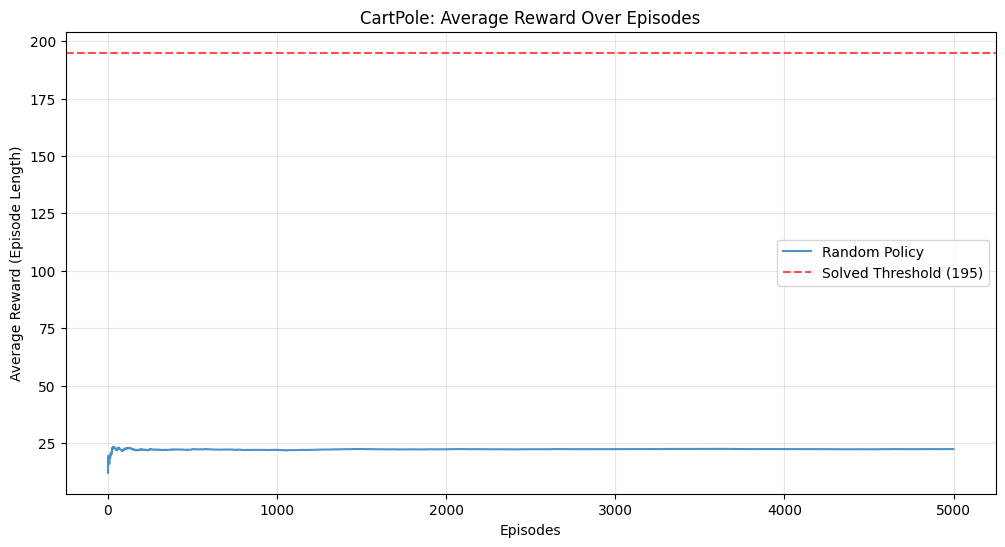

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
random_rewards = random_policy_stats['episode_rewards']
cumulative_avg_random = np.cumsum(random_rewards) / (np.arange(len(random_rewards)) + 1)
plt.plot(cumulative_avg_random, label="Random Policy", alpha=0.8)
plt.xlabel("Episodes")
plt.ylabel("Average Reward (Episode Length)")
plt.title("CartPole: Average Reward Over Episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=195, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (195)')
plt.legend()
plt.show()

In [20]:
def discretize_state(state, bins):
    """Discretize continuous state into discrete state"""
    discrete_indices = []
    for i, value in enumerate(state):
        # Clamp value to bin range
        clamped_value = np.clip(value, bins[i][0], bins[i][-1])
        bin_index = np.digitize(clamped_value, bins[i]) - 1
        bin_index = max(0, min(bin_index, len(bins[i]) - 2))
        discrete_indices.append(bin_index)

    # Use actual bin counts per dimension (handles different bin sizes)
    discrete_state = 0
    multiplier = 1
    for i, idx in enumerate(discrete_indices):
        discrete_state += idx * multiplier
        multiplier *= (len(bins[i]) - 1)
    
    return discrete_state

In [22]:
def continuous_from_discrete(discrete_state, bins):
    """Convert discrete state back to continuous state (bin centers)"""
    indices = []
    temp = discrete_state
    for i in range(len(bins)):
        n_bins = len(bins[i]) - 1
        indices.append(temp % n_bins)
        temp //= n_bins
    
    continuous_state = []
    for i, idx in enumerate(indices):
        bin_center = (bins[i][idx] + bins[i][idx + 1]) / 2
        continuous_state.append(bin_center)
    
    return np.array(continuous_state)

In [103]:
bins = [
    np.linspace(-4.8, 4.8, 7),        # Cart position 
    np.linspace(-3.0, 3.0, 7),        # Cart velocity 
    np.linspace(-0.42, 0.42, 7),      # Pole angle 
    np.linspace(-3.0, 3.0, 7)         # Pole velocity 
]

In [26]:
print(state)
discretize_state(state, bins)


[ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


np.int64(771)

In [28]:
n_bins_per_dim = len(bins[0]) - 1
n_states = n_bins_per_dim ** 4

print(f"Number of discrete states: {n_states}")

Number of discrete states: 1296


In [77]:
q_table = np.zeros((n_states, env.action_space.n))

In [79]:
q_table

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(1296, 2))

In [81]:
def calculate_epsilon_decay(epsilon, min_epsilon, decay_rate):
    epsilon = max(min_epsilon, epsilon * decay_rate)
    return epsilon

In [83]:
def first_visit_monte_carlo(q_table, episode_states, episode_actions, episode_rewards, alpha, gamma):
    visited_state_action = set()
    G = 0
    for t in reversed(range(len(episode_states)-1)):
        state_t = episode_states[t]
        action_t = episode_actions[t]
        reward_t = episode_rewards[t]

        G = reward_t + gamma * G
        if (state_t, action_t) not in visited_state_action:
            visited_state_action.add((state_t, action_t))
            q_table[state_t, action_t] += alpha*(G -q_table[state_t, action_t])
    return q_table

In [85]:
def every_visit_monte_carlo(q_table, episode_states, episode_actions, episode_rewards, alpha, gamma):
    G = 0
    for t in reversed(range(len(episode_states))):
        state_t = episode_states[t]
        action_t = episode_actions[t]
        reward_t = episode_rewards[t]

        G = reward_t + gamma*G
        q_table[state_t, action_t] += alpha*(G -q_table[state_t, action_t])
    return q_table

In [87]:
def train_monte_carlo_cartpole(bins, 
                               q_table,
                               epsilon=0.6, 
                               min_epsilon=0.1, 
                               decay_rate=0.9995, 
                               gamma=0.95, 
                               alpha=0.1,
                               n_episodes=5000,
                               first_visit=True,
                               seed=42):
    
    env = gym.make("CartPole-v1")
    env.action_space.seed(seed)
    state, info = env.reset(seed=seed)
    np.random.seed(seed)
    
    total_reward = 0
    episode_lengths = []
    episode_rewards = [] 
    
    for episode in range(n_episodes):
        state, info = env.reset()
        discrete_state = discretize_state(state, bins)
        
        episode_states = []
        episode_actions = []
        episode_rewards_per_step = []
        done = False
        episode_length = 0
        episode_reward = 0
        
        while not done:
            if np.random.rand() < epsilon:
                action = np.random.randint(env.action_space.n)
            else:
                action = np.argmax(q_table[discrete_state])
            
            next_state, reward, terminated, truncated, info = env.step(action)
            next_discrete_state = discretize_state(next_state, bins)
            
            episode_states.append(discrete_state)
            episode_actions.append(action)
            episode_rewards_per_step.append(reward)
            
            done = terminated or truncated
            episode_length += 1
            episode_reward += reward
            total_reward += reward
            
            discrete_state = next_discrete_state
            
        epsilon = calculate_epsilon_decay(epsilon, min_epsilon, decay_rate)
        
        if first_visit:
            q_table = first_visit_monte_carlo(q_table, episode_states, episode_actions, episode_rewards_per_step, alpha, gamma)
        else:
            q_table = every_visit_monte_carlo(q_table, episode_states, episode_actions, episode_rewards_per_step, alpha, gamma)

        episode_lengths.append(episode_length)
        episode_rewards.append(episode_reward)
        
        if (episode + 1) % 1000 == 0:
            recent_avg_length = np.mean(episode_lengths[-1000:])
            recent_avg_reward = np.mean(episode_rewards[-1000:])
            recent_success_rate = np.sum([r >= 195 for r in episode_rewards[-1000:]]) / 1000
            
            print(f"Episode {episode+1}: "
                  f"Avg reward = {recent_avg_reward:.2f}, "
                  f"Avg episode length = {recent_avg_length:.2f}, "
                  f"Success rate = {recent_success_rate:.1%}")
            
    env.close()
    
    stats = {
        'q_table': q_table,
        'episode_lengths': episode_lengths,
        'episode_rewards': episode_rewards,
        'mean_length': np.mean(episode_lengths),
        'std_length': np.std(episode_lengths),
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'success_rate': np.sum([r >= 195 for r in episode_rewards]) / n_episodes
    }
    
    print(f"\nFinal Monte Carlo Results:")
    print(f"Mean episode length: {stats['mean_length']:.2f} ± {stats['std_length']:.2f}")
    print(f"Mean episode reward: {stats['mean_reward']:.2f} ± {stats['std_reward']:.2f}")
    print(f"Overall success rate: {stats['success_rate']:.1%}")
    
    return stats

In [89]:
print("First-Visit Monte Carlo")
fv_mc_stats = train_monte_carlo_cartpole(
    bins,
    q_table,
    epsilon=0.95,
    min_epsilon=0.05,
    decay_rate=0.999,
    gamma=0.99,
    alpha=0.05,
    n_episodes=5000,
    first_visit=True,
    seed=42
)

First-Visit Monte Carlo
Episode 1000: Avg reward = 55.92, Avg episode length = 55.92, Success rate = 2.1%
Episode 2000: Avg reward = 120.65, Avg episode length = 120.65, Success rate = 18.0%
Episode 3000: Avg reward = 159.26, Avg episode length = 159.26, Success rate = 28.1%
Episode 4000: Avg reward = 160.41, Avg episode length = 160.41, Success rate = 28.5%
Episode 5000: Avg reward = 157.61, Avg episode length = 157.61, Success rate = 30.3%

Final Monte Carlo Results:
Mean episode length: 130.77 ± 114.20
Mean episode reward: 130.77 ± 114.20
Overall success rate: 21.4%


In [91]:
q_table = np.zeros((1296, 2))

In [93]:
print("Every-Visit Monte Carlo")
ev_mc_stats = train_monte_carlo_cartpole(
    bins,
    q_table,
    epsilon=0.95,
    min_epsilon=0.05,
    decay_rate=0.999,
    gamma=0.99,
    alpha=0.05,
    n_episodes=5000,
    first_visit=False,
    seed=42
)

Every-Visit Monte Carlo
Episode 1000: Avg reward = 61.38, Avg episode length = 61.38, Success rate = 3.9%
Episode 2000: Avg reward = 142.29, Avg episode length = 142.29, Success rate = 26.6%
Episode 3000: Avg reward = 248.14, Avg episode length = 248.14, Success rate = 53.8%
Episode 4000: Avg reward = 260.40, Avg episode length = 260.40, Success rate = 58.3%
Episode 5000: Avg reward = 244.67, Avg episode length = 244.67, Success rate = 56.7%

Final Monte Carlo Results:
Mean episode length: 191.38 ± 157.37
Mean episode reward: 191.38 ± 157.37
Overall success rate: 39.9%


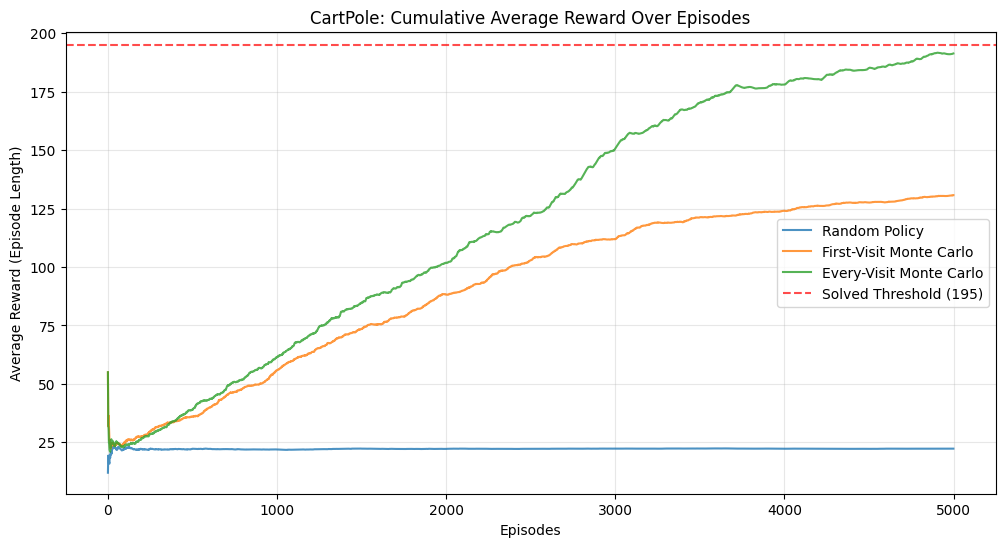

In [94]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
    
random_rewards = random_policy_stats['episode_rewards']
cumulative_avg_random = np.cumsum(random_rewards) / (np.arange(len(random_rewards)) + 1)
plt.plot(cumulative_avg_random, label="Random Policy", alpha=0.8)

fv_mc_rewards = fv_mc_stats['episode_rewards']
cumulative_avg_fv_mc = np.cumsum(fv_mc_rewards) / (np.arange(len(fv_mc_rewards)) + 1)
plt.plot(cumulative_avg_fv_mc, label="First-Visit Monte Carlo", alpha=0.8)

ev_mc_rewards = ev_mc_stats['episode_rewards']
cumulative_avg_ev_mc = np.cumsum(ev_mc_rewards) / (np.arange(len(ev_mc_rewards)) + 1)
plt.plot(cumulative_avg_ev_mc, label="Every-Visit Monte Carlo", alpha=0.8)

plt.xlabel("Episodes")
plt.ylabel("Average Reward (Episode Length)")
plt.title("CartPole: Cumulative Average Reward Over Episodes")
plt.grid(True, alpha=0.3)
    
plt.axhline(y=195, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (195)')

plt.legend()
plt.show()

In [97]:
from create_animation import visualize_episode

animation = visualize_episode(ev_mc_stats['q_table'], bins, seed=42, max_frames=195)
animation

Running episode with trained policy (seed: 42, max_frames: 195)...
Using 1,296 total discrete states
Episode length: 195
Total reward: 195.0


In [101]:
import gc
del animation
gc.collect()

6124